<h1>Analisi Dati DataSet Pinguini</h1>

In [3]:
import pandas as pandas
import numpy as numpy
import statistics as st
import matplotlib.pyplot as plt
import scipy.stats as stats

In [4]:
url=r'C:\Users\angel\OneDrive\Desktop\CORSO DATA ANALYST\DB\Penguins\penguins.csv'
penguins=pandas.read_csv(url)

## EDA

In [ ]:
penguins.head(4) #VISUALIZZO LE PRIME 4 RIGHE DEL DATAFRAME

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN


In [ ]:
penguins.tail(4) #VISUALIZZO ANCHE LE ULTIME 4 PER ASSICURARMI CHE CI SIA INTEGRITA' NEI DATI

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


Uso il metodo describe() su tutto il DataFrame:

In [ ]:
penguins.describe(include='all') #(include='all') --> INCLUDO TUTTO IL DATAFRAME ALTRIMENTI VISUALIZZEREBBE SOLO LE COLONNE CON DATI NUMERICI

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


In [8]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


Controllo da quante righe e quante colonne è composto il DataFrame.



In [9]:
penguins.shape

(344, 7)

Controllo se esistono duplicati

In [11]:
penguins.duplicated().sum()

np.int64(0)

### Descrizione del DataFrame
Il DataFrame penguins è composto da 7 colonne e 344 righe.

Le colonne:

- species è di tipo stringa. Ha solo 3 tipi di valori e contiene la specie di appartenenza del pinguino
- island è di tipo stringa. Ha solo 3 tipi di valori e contiene l'isola in cui vive il pinguino
- bill_length_mm è di tipo numerico e contiene la lunghezza del pinguino espressa in millimetri
- bill_depth_mm è di tipo numerico e contiene la larghezza del pinguino espressa in millimetri
- flipper_length_mm è di tipo  numerico e contiene la lunghezza della pinna del pinguino espressa in millimetri
- body_mass_g è di tipo numerico e contiene il peso del pinguino espresso in grammi
- sex è di tipo stringa. Ha solo 3 valori e contiene il sesso del pinguino.


## Data Cleaning

Ho riscontrato il pattern dove il sesso era uguale ad "." quindi essendo non conforme ai dati prima di creare la copia del dataframe ho eliminato la riga corrispondente andando a filtrare i dati.

In [12]:
penguinsClean=penguins[penguins['sex']!='.'].copy()

Rinomino le colonne del DataFrame in:

- species in Specie
- island in Isola
- bill_length_mm in LunghezzaMM
- bill_depth_mm in LarghezzaMM
- flipper_length_mm in LunghezzaPinnaMM
- body_mass_g in PesoGR
- sex in Sesso

In [13]:
penguinsClean.rename(
    columns={
        'species':'Specie',
        'island':'Isola',
        'bill_length_mm':'LunghezzaMM',
        'bill_depth_mm':'LarghezzaMM',
        'flipper_length_mm':'LunghezzaPinnaMM',
        'body_mass_g':'PesoGR',
        'sex':'Sesso'
}, inplace=True

)

Come si evince, eliminando la riga con "." ora il DataFrame è composto da 343 righe e 7 colonne

In [14]:
penguinsClean.shape

(343, 7)

Controllo se ci sono righe con valori nulli e in quali colonne si trovano questi ultimi 

In [15]:
penguinsClean.isnull().sum()

Specie               0
Isola                0
LunghezzaMM          2
LarghezzaMM          2
LunghezzaPinnaMM     2
PesoGR               2
Sesso               10
dtype: int64

Elimino definitivamente le righe con valori nulli, in quanto non servirebbero a nulla ai fini dell'analisi

In [ ]:
penguinsClean.dropna(inplace=True) #(inplace=True) elimina definitivamente le righe dal DataFrame

Ricontrollo che siano state eliminate realmente

In [17]:
penguinsClean.isnull().sum()

Specie              0
Isola               0
LunghezzaMM         0
LarghezzaMM         0
LunghezzaPinnaMM    0
PesoGR              0
Sesso               0
dtype: int64

Aggiungo delle colonne nelle quali converto i grammi in Kilogrammi e i millimetri in Centimetri

In [18]:
penguinsClean['PesoKG']=penguinsClean['PesoGR']/1000 
penguinsClean['LunghezzaCM']=penguinsClean['LunghezzaMM']/10 
penguinsClean['LarghezzaCM']=penguinsClean['LarghezzaMM']/10
penguinsClean['LunghezzaPinnaCM']=penguinsClean['LunghezzaPinnaMM']/10

In [19]:
penguinsClean.head()

,Specie,Isola,LunghezzaMM,LarghezzaMM,LunghezzaPinnaMM,PesoGR,Sesso,PesoKG,LunghezzaCM,LarghezzaCM,LunghezzaPinnaCM
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,3.75,3.91,1.87,18.1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,3.80,3.95,1.74,18.6
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,3.25,4.03,1.80,19.5
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,3.45,3.67,1.93,19.3
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,3.65,3.93,2.06,19.0


## Data Manipulation

### Distribuzione della Specie

Vado a calcolare come sono distribuiti i pinguini nelle varie isole, e lo faccio per specie e sesso

In [ ]:
penguinsClean.groupby(['Isola', 'Specie', 'Sesso']).agg( #GRUPPO PER ISOLA, SPECIE E SESSO
    {
        'PesoKG':['count', 'mean'], #SUL PESO VOGLIO IL CONTEGGIO E LA MEDIA
        'LunghezzaPinnaCM':['mean', 'min', 'max'] #SULLA LUNGHEZZA PINNA VOGLIO LA MEDIA, LA MINIMA E LA MASSIMA
    }
)

PesoKG           LunghezzaPinnaCM            
                            count      mean             mean   min   max
Isola     Specie    Sesso                                               
Biscoe    Adelie    FEMALE     22  3.369318        18.718182  17.2  19.9
                    MALE       22  4.050000        19.040909  18.0  20.3
          Gentoo    FEMALE     58  4.679741        21.270690  20.3  22.2
                    MALE       61  5.484836        22.154098  20.8  23.1
Dream     Adelie    FEMALE     27  3.344444        18.785185  17.8  20.2
                    MALE       28  4.045536        19.192857  17.8  20.8
          Chinstrap FEMALE     34  3.527206        19.173529  17.8  20.2
                    MALE       34  3.938971        19.991176  18.7  21.2
Torgersen Adelie    FEMALE     24  3.395833        18.829167  17.6  19.6
                    MALE       23  4.034783        19.491304  18.1  21.0

### Distribuzione totale dei pinguini per sesso, specie e isola 

In [21]:
display(penguinsClean['Sesso'].value_counts())
display(penguinsClean['Specie'].value_counts())
display(penguinsClean['Isola'].value_counts())

Sesso
MALE      168
FEMALE    165
Name: count, dtype: int64

Specie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Isola
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

## GRAFICI

### Distribuzione del peso dei pinguini - ISTOGRAMMA

Vado a calcolare come è distribuito il peso tra i vari pinguini

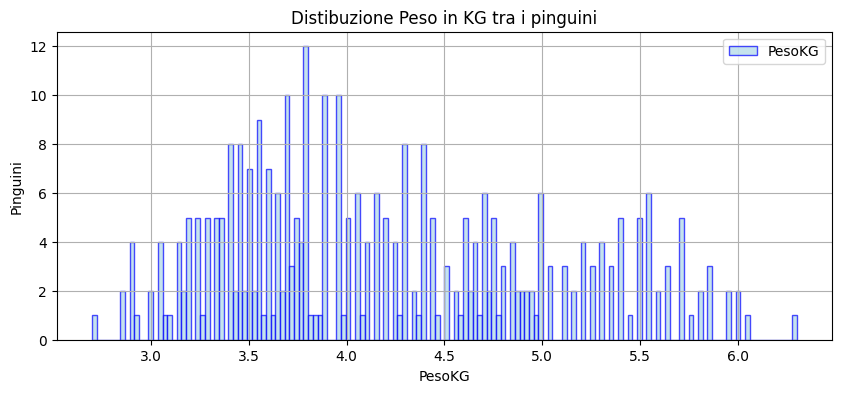

In [ ]:
graficoKGHist2 = penguinsClean['PesoKG'].plot(
    kind='hist', #SCELGO UN ISTOGRAMMA
    bins=150, #NUMERO INTERVALLI pochi=generico, tanti=dettagliato
    figsize=(10,4), #DIMENSIONI DELL'IMMAGINE
    color='lightblue', #COLORE DELLE COLONNE
    edgecolor='blue', #COLORE DEI BORDI DELLE COLONNE
    alpha=0.7, #SETTO LA TRASPARENZA - PUO' ANDARE DA 0 A 1 DOVE 0 è TRASPARENTE E 1 è COMPLETAMENTE PIENO
    legend=True, #AGGIUNGO UNA LEGENDA
    grid=True, #AGGIUNGO UNA GRIGLIA
    title='Distibuzione Peso in KG tra i pinguini',
    ylabel='Pinguini',
    xlabel='PesoKG',
    density=False #TRUE MI DARA' LA PERCENTUALE (Densità rispetto al totale) - FALSE MI DARA' IL NUMERO
    )

### Distribuzione del peso dei pinguini - KDE
kde crea una curva liscia che stima la distribuzione di probabilità di una colonna numerica, senza i "gradini" dell'istogramma. È come un istogramma + smoothing gaussiano

Media: 4.207057057057058
Mediana: 4.05


<function matplotlib.pyplot.show(close=None, block=None)>

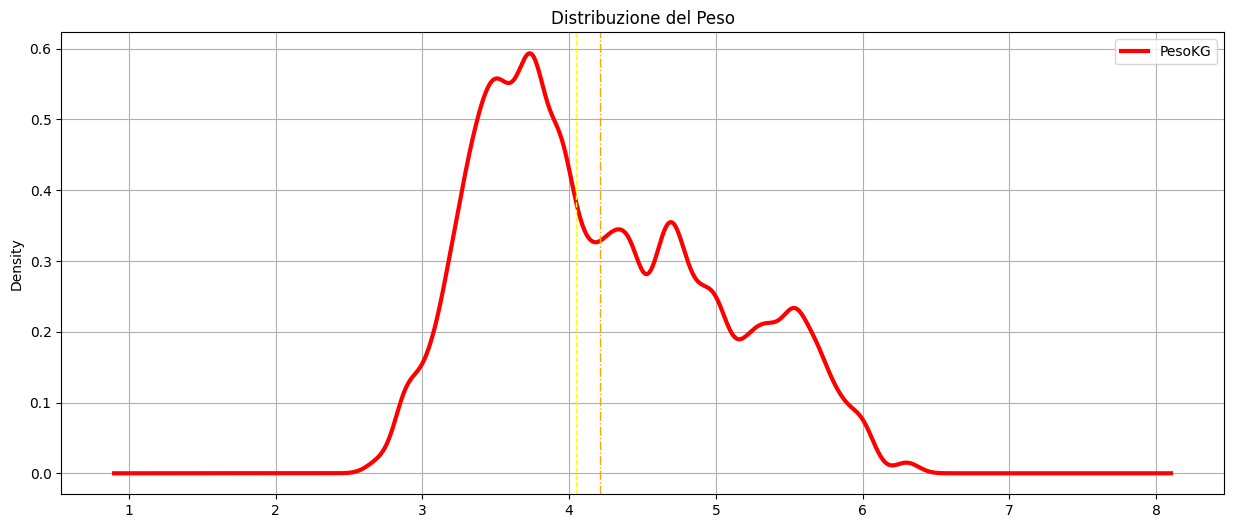

In [ ]:
graficoKGKde = penguinsClean['PesoKG'].plot(
    kind='kde', #SCELGO KDE
    color='red', #COLORE LINEA
    figsize=(15,6), #DIMENSIONI IMMAGINE
    linewidth=3, #SPESSORE LINEA
    title='Distribuzione del Peso',
    xlabel='PesoKG',
    ylabel='Pinguini',
    legend=True, #AGGIUNGO UNA LEGENDA
    grid=True, #AGGIUNGO UNA GRIGLIA
    bw_method=0.1, # 0.1=ONDULATO - 1=LISCIO
)
media=penguinsClean['PesoKG'].mean() #CALCOLO LA MEDIA
graficoKGKde.axvline(media,color='orange', linestyle='-.', linewidth=1, #LINEA MEDIA
                    label=f'Media: {media:.0f}secondi') #ETICHETTA MEDIA
print('Media:', media)
mediana=penguinsClean['PesoKG'].median() #CALCOLO LA MEDIANA
graficoKGKde.axvline(mediana,color='yellow', linestyle='--', linewidth=1, #LINEA MEDIANA
                    label=f'Mediana: {mediana:.0f}secondi') #ETICHETTA MEDIANA
print('Mediana:', mediana)
plt.show

### Distribuzione del peso dei pinguini - SCATTER
Scatter plot mostra  le relazioni tra 2 colonne numeriche (X vs Y) con punti, colore/opacità per terza variabile. 

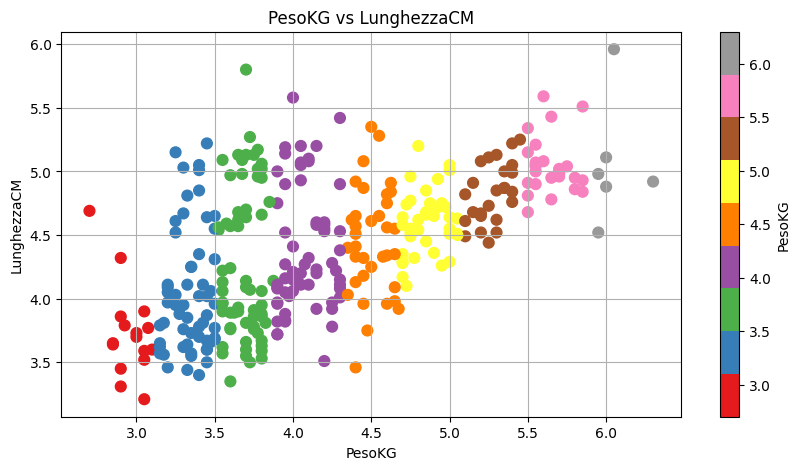

In [ ]:
graficoKGSCATTER = penguinsClean.plot(
    kind='scatter', #SCELGO SCATTER
    x='PesoKG',  # ← COLONNA X
    y='LunghezzaCM', # ← COLONNA Y
    c='PesoKG', # ← TERZA VARIABILE COLORE
    figsize=(10,5),# ← DIMENSIONE IMMAGINE
    cmap='Set1', # ← SCELGO UNA PALETTE DI COLORI
    s=60, # ← SCELGO LA DIMENSIONE DEI PUNTI
    alpha=1, # ← SETTO LA TRASPARENZA
    title='PesoKG vs LunghezzaCM',
    grid=True, #AGGIUNGO UNA GRIGLIA
    legend=True, #AGGIUNGO UNA LEGENDA
)